### Data Generation for frustrated lattices (Heisenberg J1-J2 models)

In [1]:
import matplotlib.pyplot as plt
from itertools import product
import igraph as ig
import numpy as np
from collections import defaultdict
from bitarray.util import int2ba
import pandas as pd
import seaborn as sns
import lattice_symmetries as ls

from spin_lattice_gen import SpinLattice

%matplotlib inline

In [2]:
class HeisenbergJ1J2:
    def __init__(self, lat: SpinLattice, J1: float=1., J2: float=1., use_symmetries=True):
        self.lat = lat
        
        number_spins = len(lat.sites)  # System size
        
        print(f"{number_spins=}")
        hamming_weight = number_spins // 2  # Hamming weight (i.e. number of spin ups)

        # Constructing symmetries

        if use_symmetries:
            symmetries = [ls.Symmetry(automorphism, sector=0) for automorphism in lat.get_automorphisms()]
        else:
            symmetries = []
            
        # Constructing the group
        self.symmetry_group = ls.Group(symmetries)
        print("Symmetry group contains {} elements".format(len(self.symmetry_group)))

        # Constructing the basis
        self.basis = ls.SpinBasis(
            self.symmetry_group,
            number_spins=number_spins,
            hamming_weight=hamming_weight,
            spin_inversion=1,
        )
        self.basis.build()  # Build the list of representatives, we need it since we're doing ED
        print("Hilbert space dimension is {}".format(self.basis.number_states))
        
        
        # Heisenberg Hamiltonian
        # fmt: off
        σ_x = np.array([ [0, 1]
                       , [1, 0] ])
        σ_y = np.array([ [0 , -1j]
                       , [1j,   0] ])
        σ_z = np.array([ [1,  0]
                       , [0, -1] ])
        # fmt: on
        σ_p = σ_x + 1j * σ_y
        σ_m = σ_x - 1j * σ_y

        matrix = 0.5 * (np.kron(σ_p, σ_m) + np.kron(σ_m, σ_p)) + np.kron(σ_z, σ_z)

        self.hamiltonian = ls.Operator(self.basis, 
                                       [ls.Interaction(J * matrix, edges) for J, (_, edges) in zip(
                                           [J1, J2], sorted(lat.kind_to_edges.items()))])
        
        self.ground_state = None
        self.ground_energy = None
    
    @property
    def number_spins(self):
        return len(self.lat.sites)
    
    def unpack_configurations(self):
        """
        Unpacks all configurations in the basis into an np.array 
        of one-dimensional np.arrays with 0's and 1's
        """
        unp_configs = []
        for state in self.basis.states:
            unp_config = list(int2ba(int(state)))
            unp_config = [0] * (self.number_spins - len(unp_config)) + unp_config
            unp_configs.append(unp_config)
        return np.array(unp_configs, dtype='int8')
        
    def get_ground_state(self, k=1) -> tuple[np.array, np.array]:
        """
        Records ground_energy and ground_state into to self.ground_energy and self.ground_state
        (only one value, the smallest energy) and returns k smallest eigenvalue / eigenvectors
        
        Returns
        -------
        eigenvalues : np.array
            k smallest eigenvalues
            
        eigenstates : np.array
            k eigenvectors (as vector-columns) corresponding to the k smalles eigenvalues
        
        """
        # Diagonalize the Hamiltonian using ARPACK
        eigenvalues, eigenstates = ls.diagonalize(self.hamiltonian, k=k)
        print("Ground state energy is {:.10f}".format(eigenvalues[0]))
        
        self.ground_energy = eigenvalues[0]
        self.ground_state = eigenstates[:, 0]
        
        return eigenvalues, eigenstates
        # assert np.isclose(eigenvalues[0], -18.06178542)
        
    def get_df_ground_state(self) -> pd.DataFrame:
        """
        Returns the dataframe with two columns: unpacked configuration and the corresponding
        value in the ground state
        """
        if self.ground_state is None:
            raise ValueError("Ground State was not found; run .get_groun_state() first")
            
        df = (pd.DataFrame(dict(configuration=list(self.unpack_configurations()),
                               wavefunction_value=self.ground_state))
              .assign(amplitude=lambda x: np.abs(x['wavefunction_value'])))
        
        return df
    
    def visualize_probable_configurations(self, k=0):
        """
        Visualizes k'th most probable configuration
        """
        df = self.get_df_ground_state().sort_values('amplitude', ascending=False)
        self.lat.plot(spins=df.iloc[k]['configuration'])
        plt.title(f"Plotted {k}'s most probable state, wavefunction value = {df.iloc[k]['wavefunction_value']}")

#### Chain Lattice (1dim)

In [3]:
class ChainLattice(SpinLattice):
    def __init__(self, width=1, height=1):
        """
        
        A ----- B
        
        Size of the fundamentail domain is 1×0
        """
        u = np.array([1, 0])
        v = np.array([0, 1])

        named_sites = {
            "A": np.array([0, 0]),
            "B": np.array([1, 0]),
        }

        named_edges = [
            ("AB", 1),
        ]

        super().__init__(u=u, v=v, named_sites=named_sites, named_edges=named_edges, 
                         fundamental_domain_size=np.array([1, 1]), 
                         width=width, height=height)

number_spins=10
Symmetry group contains 0 elements
Hilbert space dimension is 126
Ground state energy is -16.3688293870


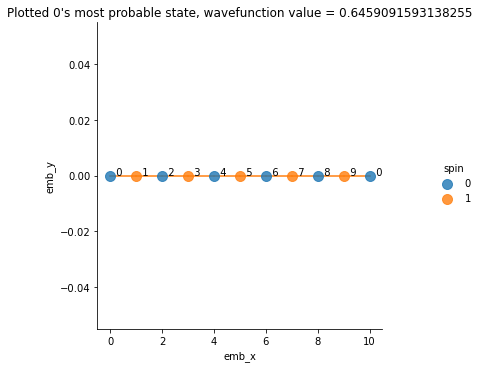

In [4]:
system_nosym = HeisenbergJ1J2(ChainLattice(width=10), J1=1, J2=0, use_symmetries=False)
energy, state = system_nosym.get_ground_state()
system_nosym.visualize_probable_configurations(k=0)

Antiferromagnetic, as expected

number_spins=10
Symmetry group contains 20 elements
Hilbert space dimension is 13
Ground state energy is -16.3688293870


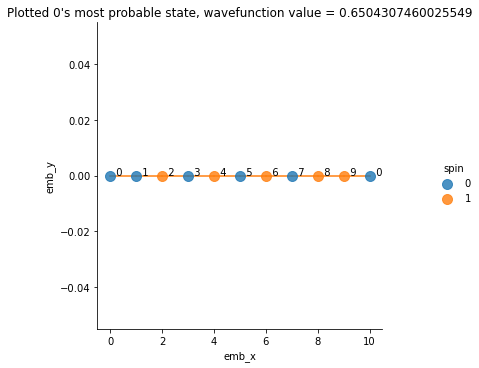

In [5]:
system_sym = HeisenbergJ1J2(ChainLattice(width=10), J1=1, J2=0, use_symmetries=True)
energy, state = system_sym.get_ground_state()
system_sym.visualize_probable_configurations(k=0)

### NB
The “most probable configuration” is not physically defined: we change it when we take symmetries into account (collapse several events into one). So the result is different for calculations with symmetries and without them.

In [6]:
class SquareLattice(SpinLattice):
    def __init__(self, width=1, height=1):
        """
        Generates square J1-J2 lattice.
        
        The fundamental domain:
        
        C ----- D
        | \\ // |
        |  \V/  |
        |  /Ʌ\  |
        | // \\ |
        A ----- B
        
        Size of the fundamentail domain is 1×1
        """
        u = np.array([1, 0])
        v = np.array([0, 1])

        named_sites = {
            "A": np.array([0, 0]),
            "B": np.array([1, 0]),
            "C": np.array([0, 1]),
            "D": np.array([1, 1])
        }

        named_edges = [
            ("AB", 1),
            ("AC", 1),
            ("CD", 1),
            ("BD", 1),
            ("CB", 2),
            ("AD", 2)
        ]

        super().__init__(u=u, v=v, named_sites=named_sites, named_edges=named_edges, fundamental_domain_size=1, 
                         width=width, height=height)

### Checks

#### 4×4 SquareLattice, J2=0

number_spins=16
Symmetry group contains 0 elements
Hilbert space dimension is 6435
Ground state energy is -44.9139328337


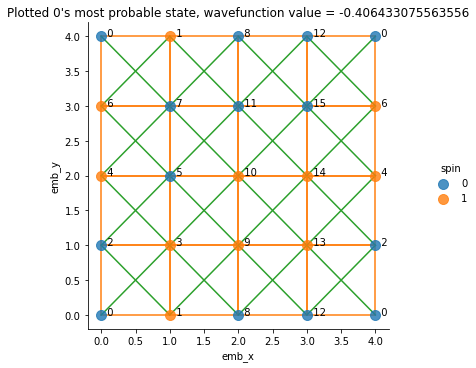

In [7]:
system_nosym = HeisenbergJ1J2(SquareLattice(width=4, height=4), J1=1, J2=0, use_symmetries=False)
system_nosym.get_ground_state()
system_nosym.visualize_probable_configurations(k=0)

No "checkerboard" pattern, probably due to additional symmetries of the square lattice (Tom)

number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Ground state energy is -44.9139328337


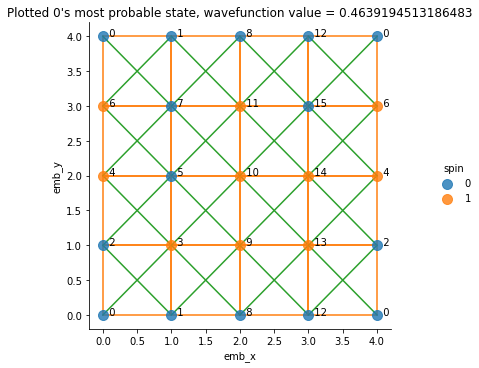

In [8]:
system_sym = HeisenbergJ1J2(SquareLattice(width=4, height=4), J1=1, J2=0, use_symmetries=True)
system_sym.get_ground_state()
system_sym.visualize_probable_configurations(k=0)

In [9]:
# with and without symmetries should give the same ground state energy
assert(np.isclose(system_sym.ground_energy, system_nosym.ground_energy))

#### Reference 4×4

In [10]:
### FROM: https://github.com/twesterhout/nqs-playground/blob/0ba67c9d4ff9f70bbaeea2a9490271dd49ea5091/benchmark/benchmark_apply.py#L9-L20
def load_basis_and_hamiltonian(filename: str):
    import yaml

    # logger.info("Loading basis from '{}'...", filename)
    with open(filename, "r") as f:
        config = yaml.load(f, Loader=yaml.SafeLoader)
    basis = ls.SpinBasis.load_from_yaml(config["basis"])
    # logger.info("Loading Hamiltonian from '{}'...", filename)
    hamiltonian = ls.Operator.load_from_yaml(config["hamiltonian"], basis)
    return basis, hamiltonian
### END FROM

In [11]:
basis, hamiltonian = load_basis_and_hamiltonian("heisenberg_square_4x4.yaml")
eigenvalues, eigenstates = ls.diagonalize(hamiltonian, k=1)
assert(np.isclose(eigenvalues[0], system_sym.ground_energy))
# energy coincides with the reference implementation

#### 6×2 lattice 

number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 462
Ground state energy is -41.2913023078


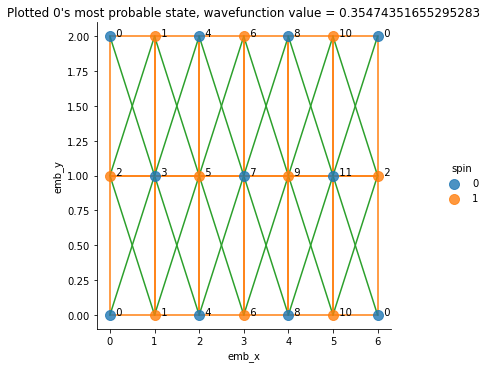

In [12]:
system_nosym = HeisenbergJ1J2(SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=False)
system_nosym.get_ground_state()
system_nosym.visualize_probable_configurations(k=0)

The checkerboard, works as expected.

number_spins=12
Symmetry group contains 24 elements
Hilbert space dimension is 44
Ground state energy is -41.2913023078


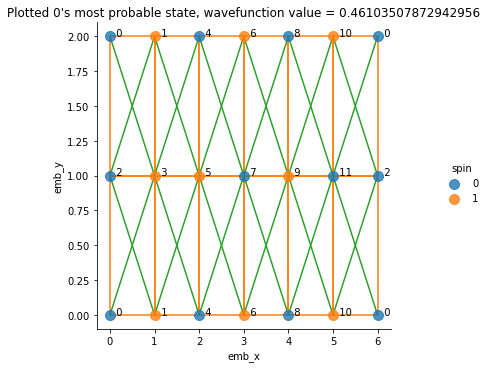

In [13]:
system_sym = HeisenbergJ1J2(SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=True)
system_sym.get_ground_state()
system_sym.visualize_probable_configurations(k=0)

### Kagome Lattice

In [14]:
class KagomeLattice(SpinLattice):
    def __init__(self, width=1, height=1):
        """
        Generates Kagome lattice.
        
        The fundamental domain:
        
             F -- G -- H
            /      \\ /
           D         E
         /  \\      /
        A -- B -- C
        
        Size of the fundamental domain is 2×2
        """
        theta = np.pi / 3
        u = np.array([1, 0])
        v = np.array([np.cos(theta), np.sin(theta)])

        named_sites = {
            "A": np.array([0, 0]),
            "B": np.array([1, 0]),
            "C": np.array([2, 0]),
            "D": np.array([0, 1]),
            "E": np.array([2, 1]),
            "F": np.array([0, 2]),
            "G": np.array([1, 2]),
            "H": np.array([2, 2]),
        }

        named_edges = [
            ("AB", 1),
            ("BC", 1),
            ("AD", 1),
            ("BD", 2),
            ("DF", 1),
            ("FG", 1),
            ("GE", 2),
            ("GH", 1),
            ("EH", 1),
            ("CE", 1),
        ]

        super().__init__(u=u, v=v, named_sites=named_sites, named_edges=named_edges, fundamental_domain_size=2, 
                         width=width, height=height)

lat.site_to_num.values()=dict_values([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 10, 0, 3, 11, 5, 8, 10, 0])
lat.kind_to_edges=defaultdict(<class 'list'>, {1: [(0, 1), (1, 2), (0, 3), (3, 5), (5, 6), (6, 7), (4, 7), (2, 4), (5, 8), (8, 0), (9, 2), (7, 9), (2, 10), (10, 0), (7, 11), (11, 5)], 2: [(1, 3), (6, 4), (6, 8), (1, 9), (10, 4), (11, 3), (11, 9), (10, 8)]})


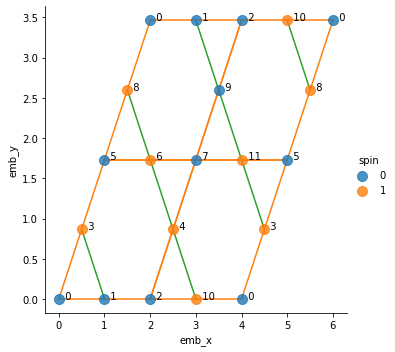

In [15]:
lat = KagomeLattice(width=2, height=2)
lat.plot(spins=np.random.randint(2, size=len(lat.sites)))
assert sorted(set(lat.site_to_num.values())) == list(range(12))
print(f"{lat.site_to_num.values()=}")
print(f"{lat.kind_to_edges=}")
#print(lat.sites_df)